#week12 / TSLA



컴퓨터공학과 / 202433638 / 장영환

순차 데이터와 시계열 데이터

순차 데이터는 순서가 중요하다.
시계열 데이터는 과거 정보가 현재 또는 미래 예측에 영향을 준다.

h_t = f_w(h_{t-1}, x_t)

현재 은닉 상태 h_t는

이전 은닉 상태 h_{t-1}와

현재 입력 x_t를 이용해 계산된다.

즉, RNN은 현재 입력만 보는 것이 아니라 이전 시점까지의 정보를 hidden state에 요약해서 함께 사용


수업 중에 다룬 sin 예제의 경우

과거 10개의 sin 값을 보고 다음 sin 값을 예측한다.
RNN이 반복되는 주기 패턴을 학습할 수 있는지 확인하는 예제

기본 RNN은 입력이 길어지면 그래디언트 소실 문제가 발생한다.

LSTM은 cell state와 gate를 이용해 중요한 정보를 더 오래 보존

#코드 진행흐름

→ Open 컬럼만 추출

→ train/test 분리

→ MinMaxScaler로 정규화

→ 7일 단위 시계열 샘플 생성

→ SimpleRNN 모델 학습

→ test 데이터 평가

→ 예측값을 원래 주가 단위로 복원

→ 실제값과 예측값 그래프 비교

In [13]:
import datetime
import time
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import tensorflow as tf

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN
from tensorflow.keras.layers import Dense

In [15]:
path = '/content/drive/MyDrive/Colab Notebooks/인공지능개론/week12/TSLA.csv'
stock = pd.read_csv(path)

In [16]:
stock

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,3.800000,5.000000,3.508000,4.778000,4.778000,93831500
1,2010-06-30,5.158000,6.084000,4.660000,4.766000,4.766000,85935500
2,2010-07-01,5.000000,5.184000,4.054000,4.392000,4.392000,41094000
3,2010-07-02,4.600000,4.620000,3.742000,3.840000,3.840000,25699000
4,2010-07-06,4.000000,4.000000,3.166000,3.222000,3.222000,34334500
...,...,...,...,...,...,...,...
2951,2022-03-18,874.489990,907.849976,867.390015,905.390015,905.390015,33408500
2952,2022-03-21,914.979980,942.849976,907.090027,921.159973,921.159973,27327200
2953,2022-03-22,930.000000,997.859985,921.750000,993.979980,993.979980,35289500
2954,2022-03-23,979.940002,1040.699951,976.400024,999.109985,999.109985,40225400


In [17]:
stock = (stock [['Open']]).to_numpy()

In [18]:
stock

array([[   3.8     ],
       [   5.158   ],
       [   5.      ],
       ...,
       [ 930.      ],
       [ 979.940002],
       [1009.72998 ]])

In [19]:
# 입력 x: 7일치 Open 가격
# 정답 y: 그 다음 날 Open 가격

def make_sample(data, window):
    train = []                                      # 공백 리스트 생성
    target = []
    for i in range(len(data)-window):               # 데이터의 길이만큼 반복
        train.append(data[i:i+window])              # i부터 (i+window-1) 까지를 저장
        target.append(data[i+window])               # (i+window) 번째 요소는 정답
    return np.array(train), np.array(target)         # 파이썬 리스트를 넘파이로 변환

In [20]:
# 윈도우 크기
window = 7

# train/test 분리
split = int(len(stock) * 0.8)

train = stock[:split]
test = stock[split-window:]

주가 데이터는 값의 범위가 크다. 초반에는 몇 달러 수준이고, 후반에는 1000달러 이상까지 간다.

이런 값을 그대로 RNN에 넣으면 학습이 불안정해질 수 있다.

그래서 MinMaxScaler를 사용해 값을 변환

In [21]:
# 정규화
scaler = MinMaxScaler()
train = scaler.fit_transform(train) #train 데이터의 최솟값, 최댓값을 기준으로 정규화
test = scaler.transform(test) #train에서 구한 기준을 test에 그대로 적용

| 구분              | 의미               | 코드 예시          |
| --------------- | ---------------- | -------------- |
| `window size`   | 과거 몇 개 시점을 볼 것인가 | `window = 7`   |
| `feature 수`     | 한 시점에 들어가는 변수 개수 | Open만 쓰면 `1`   |
| `hidden unit 수` | RNN 내부 기억 벡터 크기  | `SimpleRNN(3)` |


x shape: (2357, 7, 1)
y shape: (2357, 1)
x_test shape: (592, 7, 1)
y_test shape: (592, 1)
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4731 - mae: 0.5670
Epoch 2/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2834 - mae: 0.4648
Epoch 3/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1743 - mae: 0.3809
Epoch 4/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1097 - mae: 0.3092
Epoch 5/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0751 - mae: 0.2528
Epoch 6/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0582 - mae: 0.2132
Epoch 7/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0490 - mae: 0.1863
Epoch 8/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0419 - mae: 0.1667
Epoch 9/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0352 - mae: 0.1498
Epoch 10/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0283 - mae: 0.1327
Epoch 11/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0213 - mae: 0.1134
Epoch 12/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0141 - mae: 0.0909
Epoch 13/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/st

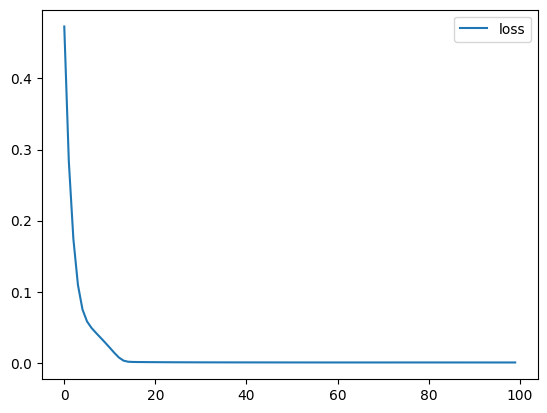

In [22]:
x, y = make_sample(train, window)
x_test, y_test = make_sample(test, window)

print("x shape:", x.shape)
print("y shape:", y.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

model = Sequential()
model.add(SimpleRNN(3, activation='tanh', input_shape=(7, 1))) # 3은 RNN 뉴런 수, 즉 hidden unit 수
# model.add(Dense(1, activation='tanh'))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

history = model.fit(x, y, epochs=100, verbose=1, shuffle=False)

plt.plot(history.history['loss'], label="loss")
plt.legend()
plt.show()

Test MSE: 64.90247344970703
Test MAE: 6.669914245605469
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Test MAE in price: 494.3073139950908
Test RMSE in price: 597.0455072461492


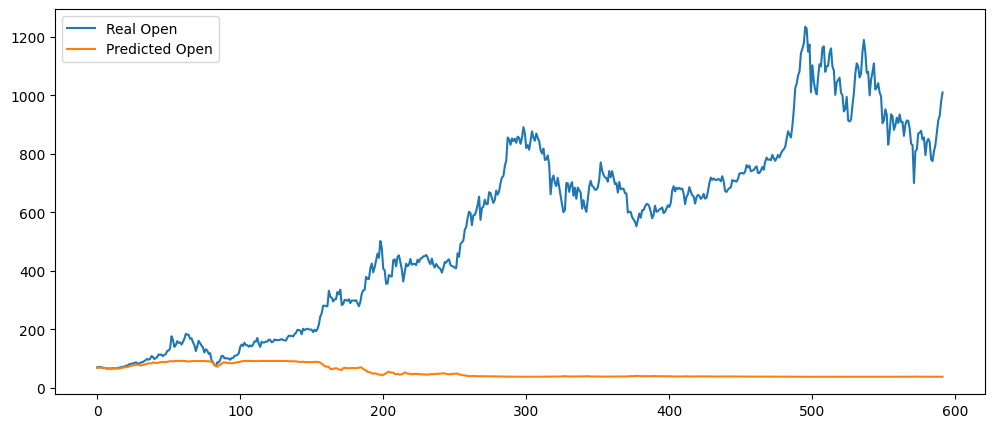

In [23]:
# test 데이터로 성능 확인
test_loss, test_mae = model.evaluate(x_test, y_test, verbose=0)

print("Test MSE:", test_loss)
print("Test MAE:", test_mae)

# test 데이터 예측
pred = model.predict(x_test)

# 원래 주가 단위로 복원
pred_price = scaler.inverse_transform(pred)
real_price = scaler.inverse_transform(y_test)

# 원래 주가 단위에서 오차 계산
mae_price = np.mean(np.abs(real_price - pred_price))
rmse_price = np.sqrt(np.mean((real_price - pred_price) ** 2))

print("Test MAE in price:", mae_price)
print("Test RMSE in price:", rmse_price)

# 실제값과 예측값 비교
plt.figure(figsize=(12, 5))
plt.plot(real_price, label='Real Open')
plt.plot(pred_price, label='Predicted Open')
plt.legend()
plt.show()

#왜 test 성능이 나쁜가

코드는 앞의 80% 데이터를 train으로, 뒤의 20% 데이터를 test로 사용한다.

TSLA는 후반부에 가격이 급격히 상승했다.
따라서 train 구간에서는 상대적으로 낮은 가격대를 보고 학습했는데, test 구간에서는 훨씬 높은 가격대가 등장

또한 주가는 예측 난도가 높은 데이터다

주가는 단순한 수열이 아니라 시장 심리, 뉴스, 금리, 실적, 거래량 등 다양한 요인의 영향을 받는다